# Temporal 2D--3D agreement metrics

This notebook compares a 3D case with its corresponding 2D case, using
the naming convention:

- `run_jun1`
- `run_jun1_2D`

A user-defined time window is applied consistently to the flow and
particle comparisons.

The notebook computes:

1. **Scalar distances between distributions**
   - Wasserstein distance between 2D and 3D flow-diagnostic distributions.
   - Wasserstein distance between normalized Voronoï-area distributions.

2. **Coarse-grained particle-field agreement**
   - Spearman correlation and normalized RMSE of coarse particle-density
     fields.

3. **Particle-clustering error**
   - Signed, absolute and relative differences in clustered-particle
     fraction through time.

4. **Submesoscale-active area fraction**
   - The temporal fraction of the domain satisfying
     \(\left|\zeta_z/f\right|>0.5\).
   - A selected-case figure using the same \(4\times4\) physical
     subdivision for the 2D and 3D domains.
   - Complete-domain summaries across all available 2D--3D case pairs.

The notebook expects trajectory collections from `run_particles.ipynb`
and clustered-state NetCDF files from `analyze_particles.ipynb`.


In [1]:
# ============================================================
# 1. IMPORTS AND PROJECT PATHS
# ============================================================

from pathlib import Path
import sys
import importlib
import json
import warnings

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from scipy.stats import wasserstein_distance, spearmanr


# Notebook location:
# THESIS/z.parcels_postprocessing/notebooks/compare_2D_3D_agreement_metrics.ipynb
NB_DIR = Path.cwd().resolve()
PROJECT_DIR = NB_DIR.parent.parent

for path in [
    PROJECT_DIR,
    PROJECT_DIR / "z.flow_postprocessing",
    PROJECT_DIR / "z.parcels_postprocessing",
]:
    path = str(path)
    if path not in sys.path:
        sys.path.insert(0, path)


import scripts.run as prun
import scripts.metrics_clustering as mclus
import scripts.notebook_helpers as phelp
import theme.plot_theme as ptheme

for module in [prun, mclus, phelp, ptheme]:
    importlib.reload(module)

ptheme.apply_theme()

print(f"Notebook dir : {NB_DIR}")
print(f"Project dir  : {PROJECT_DIR}")
print(f"run.py       : {Path(prun.__file__).resolve()}")
print(f"clustering   : {Path(mclus.__file__).resolve()}")


Notebook dir : C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\notebooks
Project dir  : C:\Users\Jelle Gortemaker\Documents\Thesis
run.py       : C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\scripts\run.py
clustering   : C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\scripts\metrics_clustering.py


In [2]:
# ============================================================
# 2. CASE, TIME-RANGE AND ANALYSIS SETTINGS
# ============================================================

# Selected pair used for the detailed flow, particle and 4x4 figures.
CASE_3D = "run_jun1"
CASE_2D = f"{CASE_3D}_2D"

INPUT_DIR = (NB_DIR / "../data/input").resolve()
RESULTS_ROOT = (NB_DIR / "../results").resolve()

DATA_FILE_3D = INPUT_DIR / f"{CASE_3D}.nc"
DATA_FILE_2D = INPUT_DIR / f"{CASE_2D}.nc"

CASE_RESULTS_3D = RESULTS_ROOT / CASE_3D
CASE_RESULTS_2D = RESULTS_ROOT / CASE_2D

# Set either value to None to use the newest config in metadata/.
RUN_COLLECTION_ID_3D = None
RUN_COLLECTION_ID_2D = None

# ------------------------------------------------------------
# Comparison time window, measured from the particle-release time.
#
# Use None for an open bound:
#   COMPARISON_START_DAY = None
#   COMPARISON_END_DAY = None
# ------------------------------------------------------------
COMPARISON_START_DAY = 0.0
COMPARISON_END_DAY = 14.0

# Fallback used only when no collection metadata is available for a case
# in the multi-case active-area summary.
DEFAULT_FLOW_TIME_STEP_SECONDS = 3 * 3600
DEFAULT_RELEASE_TIME_INDEX = 0

FLOW_DISTRIBUTION_VARIABLES = {
    "ro": r"$\zeta_z/f$",
    "strain_f": r"$s/f$",
    "div_f": r"$\delta/f$",
}

F0 = 8.0e-5
FLOW_LEVEL_INDICES_3D = (0,)
FLOW_LEVEL_INDICES_2D = (0,)

# Submesoscale-active criterion.
ACTIVE_RO_THRESHOLD = 0.5

# The selected case is divided into the same physical 4x4 blocks.
ACTIVE_SUBDOMAINS_X = 4
ACTIVE_SUBDOMAINS_Y = 4

# Cases used in the complete-domain summary:
# - None: automatically discover every run_*.nc / run_*_2D.nc pair.
# - A list: use only the explicitly selected 3D case names.
SUMMARY_CASES_3D = None
EXCLUDE_SUMMARY_CASES_3D = []

# Deterministic subsampling for Wasserstein calculations.
# Set to None to use every finite grid value.
MAX_DISTRIBUTION_SAMPLES = 150_000

# Coarse-grained particle-density grid.
N_BLOCKS_X = 16
N_BLOCKS_Y = 16
MIN_VALID_BLOCKS_FOR_CORRELATION = 8

CLUSTER_FRACTION_RELATIVE_ERROR_FLOOR = 1.0e-3

PLOT_SPATIAL_DIFFERENCE_MAPS = True
SPATIAL_MAP_TIME_DAYS = [3.0, 6.0, 9.0, 12.0, 14.0]

SAVE_OUTPUTS = True
SAVE_FIGURES = True


def _day_tag(value, open_label):
    if value is None:
        return open_label
    return f"{float(value):g}".replace("-", "m").replace(".", "p")


TIME_RANGE_TAG = (
    f"T{_day_tag(COMPARISON_START_DAY, 'start')}"
    f"-{_day_tag(COMPARISON_END_DAY, 'end')}d"
)

COMPARISON_ID = f"{CASE_3D}_vs_{CASE_2D}_{TIME_RANGE_TAG}"
OUTPUT_DIR = RESULTS_ROOT / "comparisons" / COMPARISON_ID
METRICS_DIR = OUTPUT_DIR / "metrics"
FIG_DIR = OUTPUT_DIR / "figures"

if SAVE_OUTPUTS:
    METRICS_DIR.mkdir(parents=True, exist_ok=True)

if SAVE_FIGURES:
    FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"3D input     : {DATA_FILE_3D}")
print(f"2D input     : {DATA_FILE_2D}")
print(
    "Time range   : "
    f"{COMPARISON_START_DAY} to {COMPARISON_END_DAY} days"
)
print(f"Output dir   : {OUTPUT_DIR}")


3D input     : C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\data\input\run_jun1.nc
2D input     : C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\data\input\run_jun1_2D.nc
Time range   : 0.0 to 14.0 days
Output dir   : C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\comparisons\run_jun1_vs_run_jun1_2D_T0-14d


## Metric interpretation

For a variable \(q\), the first Wasserstein distance is

\[
W_1(q_{\mathrm{2D}},q_{\mathrm{3D}}),
\]

where \(W_1=0\) indicates identical distributions. An IQR-normalized value is also stored:

\[
W_{1,\mathrm{norm}} = \frac{W_1}{\mathrm{IQR}_{\mathrm{3D}}}.
\]

The coarse-grained particle-field agreement is summarized by:

- **Spearman correlation**: \(1\) indicates identical spatial rank ordering of dense and sparse blocks.
- **Normalized RMSE**: \(0\) indicates identical coarse particle-density fields.

The signed clustering error is

\[
\Delta F_c(t)=F_c^{\mathrm{2D}}(t)-F_c^{\mathrm{3D}}(t),
\]

so positive values indicate stronger clustering in 2D.


In [3]:
# ============================================================
# 3. GENERAL HELPERS
# ============================================================

def newest_collection_config(case_results_dir, collection_id=None):
    metadata_dir = Path(case_results_dir) / "metadata"

    if collection_id is not None:
        path = metadata_dir / f"{collection_id}_config.json"
        if not path.exists():
            raise FileNotFoundError(path)
        return path

    candidates = sorted(
        metadata_dir.glob("*_config.json"),
        key=lambda p: p.stat().st_mtime,
    )

    if not candidates:
        raise FileNotFoundError(
            f"No *_config.json files found in {metadata_dir}"
        )

    return candidates[-1]


def elapsed_days_from_trajectory(ds_traj):
    if "time" not in ds_traj:
        return np.asarray(ds_traj["obs"].values, dtype=float)

    time_da = ds_traj["time"]

    for dim in ["trajectory", "particle"]:
        if dim in time_da.dims:
            time_da = time_da.median(dim=dim, skipna=True)

    values = np.asarray(time_da.values)

    if np.issubdtype(values.dtype, np.datetime64):
        valid = ~np.isnat(values)
        if not np.any(valid):
            return np.full(values.shape, np.nan, dtype=float)
        t0 = values[np.flatnonzero(valid)[0]]
        return ((values - t0) / np.timedelta64(1, "D")).astype(float)

    values = values.astype(float)
    valid = np.isfinite(values)

    if not np.any(valid):
        return np.full(values.shape, np.nan, dtype=float)

    t0 = values[np.flatnonzero(valid)[0]]
    return (values - t0) / 86400.0


def nearest_time_matches(time_reference, time_other, tolerance_days=None):
    time_reference = np.asarray(time_reference, dtype=float)
    time_other = np.asarray(time_other, dtype=float)

    valid_reference = np.isfinite(time_reference)
    valid_other = np.isfinite(time_other)

    reference_indices = np.flatnonzero(valid_reference)
    other_indices = np.flatnonzero(valid_other)

    reference_values = time_reference[valid_reference]
    other_values = time_other[valid_other]

    if reference_values.size == 0 or other_values.size == 0:
        return np.array([], dtype=int), np.array([], dtype=int)

    if tolerance_days is None:
        dt_reference = (
            np.nanmedian(np.diff(reference_values))
            if reference_values.size > 1
            else np.nan
        )
        dt_other = (
            np.nanmedian(np.diff(other_values))
            if other_values.size > 1
            else np.nan
        )
        candidates = [
            dt for dt in [dt_reference, dt_other]
            if np.isfinite(dt) and dt > 0
        ]
        tolerance_days = 0.51 * max(candidates) if candidates else 1.0e-8

    matched_reference = []
    matched_other = []

    for local_index, value in enumerate(reference_values):
        nearest_other = int(np.argmin(np.abs(other_values - value)))

        if abs(other_values[nearest_other] - value) <= tolerance_days:
            matched_reference.append(reference_indices[local_index])
            matched_other.append(other_indices[nearest_other])

    return (
        np.asarray(matched_reference, dtype=int),
        np.asarray(matched_other, dtype=int),
    )


def deterministic_subsample(values, max_samples):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if max_samples is None or values.size <= int(max_samples):
        return values

    step = int(np.ceil(values.size / int(max_samples)))
    return values[::step]


def normalized_wasserstein(values_2d, values_3d, max_samples=None):
    values_2d = deterministic_subsample(values_2d, max_samples)
    values_3d = deterministic_subsample(values_3d, max_samples)

    if values_2d.size == 0 or values_3d.size == 0:
        return np.nan, np.nan

    raw = float(wasserstein_distance(values_2d, values_3d))

    q25, q75 = np.nanpercentile(values_3d, [25.0, 75.0])
    iqr = float(q75 - q25)

    normalized = raw / iqr if np.isfinite(iqr) and iqr > 0.0 else np.nan
    return raw, normalized


def infer_domain_from_mitgcm(path):
    with xr.open_dataset(path, decode_times=False, cache=False) as ds:
        x = np.asarray(ds["X"].values, dtype=float)
        y = np.asarray(ds["Y"].values, dtype=float)

    dx = float(np.nanmedian(np.diff(x)))
    dy = float(np.nanmedian(np.diff(y)))

    return mclus.PeriodicDomain(
        x_min=float(x[0] - 0.5 * dx),
        x_max=float(x[-1] + 0.5 * dx),
        y_min=float(y[0] - 0.5 * dy),
        y_max=float(y[-1] + 0.5 * dy),
    )


def particle_class_key(item):
    info = item.get("info", {}) or {}
    spec = item.get("spec", {}) or {}

    particle_class = info.get(
        "particle_class",
        spec.get("particle_class"),
    )

    tau_eff = None

    for source in [info, spec]:
        for name in [
            "tau_eff_seconds",
            "tau_eff_nominal_seconds",
            "tau_p_seconds",
        ]:
            if source.get(name) is not None:
                tau_eff = float(source[name])
                break
        if tau_eff is not None:
            break

    if (
        particle_class == "passive"
        or tau_eff is None
        or abs(tau_eff) < 1.0e-12
    ):
        return "passive", 0.0

    rounded = int(round(tau_eff))
    return f"tau_eff_{rounded}s", float(tau_eff)


def map_particle_classes(trajectories):
    mapped = {}

    for tag, item in trajectories.items():
        key, tau_eff = particle_class_key(item)

        if key in mapped:
            raise RuntimeError(
                f"Duplicate particle class key {key}. "
                "Adjust particle_class_key() if needed."
            )

        mapped[key] = {
            "tag": tag,
            "tau_eff_seconds": tau_eff,
            "label": item.get(
                "display_label",
                item.get("label", tag),
            ),
            **item,
        }

    return mapped


def normalized_particle_histogram(x, y, domain, nx, ny):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    x, y = mclus.wrap_to_domain(x, y, domain)
    valid = np.isfinite(x) & np.isfinite(y)

    x_edges = np.linspace(domain.x_min, domain.x_max, int(nx) + 1)
    y_edges = np.linspace(domain.y_min, domain.y_max, int(ny) + 1)

    counts, _, _ = np.histogram2d(
        x[valid],
        y[valid],
        bins=[x_edges, y_edges],
    )

    total = float(np.sum(counts))
    density = (
        counts / total
        if total > 0.0
        else np.full_like(counts, np.nan)
    )

    return density, x_edges, y_edges


def coarse_particle_agreement(
    density_2d,
    density_3d,
    min_valid_blocks=8,
):
    values_2d = np.asarray(density_2d, dtype=float).ravel()
    values_3d = np.asarray(density_3d, dtype=float).ravel()

    valid = np.isfinite(values_2d) & np.isfinite(values_3d)

    if np.count_nonzero(valid) < int(min_valid_blocks):
        return np.nan, np.nan

    values_2d = values_2d[valid]
    values_3d = values_3d[valid]

    if (
        np.allclose(values_2d, values_2d[0])
        or np.allclose(values_3d, values_3d[0])
    ):
        rho = np.nan
    else:
        rho = float(spearmanr(values_2d, values_3d).statistic)

    rmse = float(
        np.sqrt(np.mean((values_2d - values_3d) ** 2))
    )
    reference_rms = float(
        np.sqrt(np.mean(values_3d ** 2))
    )
    nrmse = rmse / reference_rms if reference_rms > 0.0 else np.nan

    return rho, nrmse



def time_range_mask(
    time_days,
    start_day=COMPARISON_START_DAY,
    end_day=COMPARISON_END_DAY,
):
    """Return a finite-time mask for the selected comparison window."""
    time_days = np.asarray(time_days, dtype=float)
    mask = np.isfinite(time_days)

    if start_day is not None:
        mask &= time_days >= float(start_day) - 1.0e-12

    if end_day is not None:
        mask &= time_days <= float(end_day) + 1.0e-12

    return mask


def time_is_selected(
    time_day,
    start_day=COMPARISON_START_DAY,
    end_day=COMPARISON_END_DAY,
):
    return bool(
        time_range_mask(
            np.asarray([time_day], dtype=float),
            start_day=start_day,
            end_day=end_day,
        )[0]
    )


def comparison_time_label():
    start = (
        "first available"
        if COMPARISON_START_DAY is None
        else f"{COMPARISON_START_DAY:g}"
    )
    end = (
        "last available"
        if COMPARISON_END_DAY is None
        else f"{COMPARISON_END_DAY:g}"
    )
    return f"T={start}--{end} days"


def discover_2d_3d_case_pairs(input_dir):
    """Find run_name.nc / run_name_2D.nc pairs."""
    input_dir = Path(input_dir)
    cases = []

    for path_3d in sorted(input_dir.glob("run_*.nc")):
        case_3d = path_3d.stem

        if case_3d.endswith("_2D"):
            continue

        path_2d = input_dir / f"{case_3d}_2D.nc"

        if path_2d.exists():
            cases.append(case_3d)

    return cases


def optional_case_config(case_name):
    """
    Read the newest particle-collection config when available.

    The complete-domain active-area analysis can still run without it,
    using the configured fallback release index and forcing interval.
    """
    try:
        config_path = newest_collection_config(
            RESULTS_ROOT / case_name,
            collection_id=None,
        )
        with open(config_path, "r", encoding="utf-8") as config_file:
            return json.load(config_file)
    except (FileNotFoundError, OSError, json.JSONDecodeError):
        return {
            "release_time_index": int(DEFAULT_RELEASE_TIME_INDEX),
            "time_step_seconds": float(
                DEFAULT_FLOW_TIME_STEP_SECONDS
            ),
        }


In [4]:
# ============================================================
# 4. LOAD BOTH TRAJECTORY COLLECTIONS
# ============================================================

CONFIG_3D = newest_collection_config(
    CASE_RESULTS_3D,
    RUN_COLLECTION_ID_3D,
)
CONFIG_2D = newest_collection_config(
    CASE_RESULTS_2D,
    RUN_COLLECTION_ID_2D,
)

trajectories_3d_raw, config_3d = (
    phelp.load_trajectory_collection_from_config(
        CONFIG_3D,
        loader=prun.load_trajectories,
        load=False,
    )
)

trajectories_2d_raw, config_2d = (
    phelp.load_trajectory_collection_from_config(
        CONFIG_2D,
        loader=prun.load_trajectories,
        load=False,
    )
)

trajectories_3d = map_particle_classes(trajectories_3d_raw)
trajectories_2d = map_particle_classes(trajectories_2d_raw)

common_particle_classes = sorted(
    set(trajectories_3d) & set(trajectories_2d),
    key=lambda key: trajectories_3d[key]["tau_eff_seconds"],
)

if not common_particle_classes:
    raise RuntimeError("No common particle classes were found.")

domain_3d = infer_domain_from_mitgcm(DATA_FILE_3D)
domain_2d = infer_domain_from_mitgcm(DATA_FILE_2D)

domain_values_3d = np.array([
    domain_3d.x_min,
    domain_3d.x_max,
    domain_3d.y_min,
    domain_3d.y_max,
])
domain_values_2d = np.array([
    domain_2d.x_min,
    domain_2d.x_max,
    domain_2d.y_min,
    domain_2d.y_max,
])

if not np.allclose(domain_values_3d, domain_values_2d):
    raise ValueError(
        "The 2D and 3D domains differ. "
        "An explicit remapping step is required."
    )

domain = domain_3d

print("\nSelected collections")
print(f"  3D: {CONFIG_3D}")
print(f"  2D: {CONFIG_2D}")

print("\nCommon particle classes")
for key in common_particle_classes:
    print(
        f"  {key:18s} | "
        f"3D tag={trajectories_3d[key]['tag']} | "
        f"2D tag={trajectories_2d[key]['tag']}"
    )

print(
    f"\nCommon domain: {domain.Lx / 1000.0:.1f} x "
    f"{domain.Ly / 1000.0:.1f} km"
)



Trajectory QC: passive
  label     : Tracer
  path      : C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1\trajectories\passive_k0_release_t0000.zarr
  dims      : {'trajectory': 3600, 'obs': 112}
  variables : ['B', 'C_Rep', 'C_Rep_current', 'Rep', 'diameter', 'drag_mode_id', 'lat', 'lon', 'particle_class_id', 'release_id', 'stokes_number', 'tau_eff_nominal', 'tau_p', 'time', 'up', 'uslip', 'vp', 'vslip', 'z']

Trajectory QC: smmrg_taueff30s_Steff4p21421em05
  label     : SM-MRG, tau_eff=0.00833333 h, St_eff=4.21e-05
  path      : C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1\trajectories\smmrg_taueff30s_Steff4p21421em05_k0_release_t0000.zarr
  dims      : {'trajectory': 3600, 'obs': 112}
  variables : ['B', 'C_Rep', 'C_Rep_current', 'Rep', 'diameter', 'drag_mode_id', 'lat', 'lon', 'particle_class_id', 'release_id', 'stokes_number', 'tau_eff_nominal', 'tau_p', 'time', 'up', 'uslip', 'vp', 'vslip', 'z']

Trajec

In [5]:
# ============================================================
# 5. MEMORY-LIGHT FLOW-SNAPSHOT HELPERS
# ============================================================

def find_vertical_dim(ds):
    for dim in ds["UVEL"].dims:
        if dim.startswith("Z") or dim.lower() in {
            "z",
            "depth",
            "k",
            "level",
            "lev",
        }:
            return dim
    return None


def centered_uv_snapshot(ds, time_index, level_indices):
    x = np.asarray(ds["X"].values, dtype=float)
    y = np.asarray(ds["Y"].values, dtype=float)

    nx = x.size
    ny = y.size
    z_dim = find_vertical_dim(ds)

    U_layers = []
    V_layers = []

    for level_index in level_indices:
        selection = {"T": int(time_index)}

        if z_dim is not None:
            selection[z_dim] = int(level_index)

        u_raw = np.asarray(
            ds["UVEL"].isel(selection).values,
            dtype=float,
        ).squeeze()

        v_raw = np.asarray(
            ds["VVEL"].isel(selection).values,
            dtype=float,
        ).squeeze()

        if u_raw.shape == (ny, nx + 1):
            U = 0.5 * (u_raw[:, :-1] + u_raw[:, 1:])
        elif u_raw.shape == (ny, nx):
            U = u_raw
        else:
            raise ValueError(
                f"Unexpected UVEL shape {u_raw.shape}; "
                f"expected {(ny, nx + 1)} or {(ny, nx)}."
            )

        if v_raw.shape == (ny + 1, nx):
            V = 0.5 * (v_raw[:-1, :] + v_raw[1:, :])
        elif v_raw.shape == (ny, nx):
            V = v_raw
        else:
            raise ValueError(
                f"Unexpected VVEL shape {v_raw.shape}; "
                f"expected {(ny + 1, nx)} or {(ny, nx)}."
            )

        U_layers.append(U)
        V_layers.append(V)

    U = np.nanmean(np.stack(U_layers, axis=0), axis=0)
    V = np.nanmean(np.stack(V_layers, axis=0), axis=0)

    return U, V, x, y


def flow_diagnostics_snapshot(ds, time_index, level_indices, f0):
    U, V, x, y = centered_uv_snapshot(
        ds,
        time_index,
        level_indices,
    )

    dx = float(np.nanmedian(np.diff(x)))
    dy = float(np.nanmedian(np.diff(y)))

    dUdy, dUdx = np.gradient(U, dy, dx, edge_order=2)
    dVdy, dVdx = np.gradient(V, dy, dx, edge_order=2)

    zeta = dVdx - dUdy
    divergence = dUdx + dVdy
    strain = np.sqrt(
        (dUdx - dVdy) ** 2
        + (dVdx + dUdy) ** 2
    )

    return {
        "ro": zeta / float(f0),
        "strain_f": strain / float(f0),
        "div_f": divergence / float(f0),
    }


def flow_elapsed_days(config, n_times):
    release_index = int(
        config.get(
            "release_time_index",
            DEFAULT_RELEASE_TIME_INDEX,
        )
    )
    dt_seconds = float(
        config.get(
            "time_step_seconds",
            DEFAULT_FLOW_TIME_STEP_SECONDS,
        )
    )

    return (
        np.arange(n_times, dtype=float) - release_index
    ) * dt_seconds / 86400.0


def active_area_fraction(ro, threshold=ACTIVE_RO_THRESHOLD):
    """Fraction of finite cells satisfying |zeta_z/f| > threshold."""
    ro = np.asarray(ro, dtype=float)
    valid = np.isfinite(ro)

    if not np.any(valid):
        return np.nan

    return float(
        np.mean(np.abs(ro[valid]) > float(threshold))
    )


def active_area_fraction_blocks(
    ro,
    n_blocks_y=ACTIVE_SUBDOMAINS_Y,
    n_blocks_x=ACTIVE_SUBDOMAINS_X,
    threshold=ACTIVE_RO_THRESHOLD,
):
    """
    Calculate active-area fractions in equal physical domain fractions.

    Using np.array_split ensures that the same relative 4x4 domain regions
    are used when the 2D and 3D grids have different resolutions.
    """
    ro = np.asarray(ro, dtype=float)

    y_groups = np.array_split(
        np.arange(ro.shape[0]),
        int(n_blocks_y),
    )
    x_groups = np.array_split(
        np.arange(ro.shape[1]),
        int(n_blocks_x),
    )

    fractions = np.full(
        (int(n_blocks_y), int(n_blocks_x)),
        np.nan,
        dtype=float,
    )

    for block_y, y_indices in enumerate(y_groups):
        for block_x, x_indices in enumerate(x_groups):
            block = ro[np.ix_(y_indices, x_indices)]
            fractions[block_y, block_x] = active_area_fraction(
                block,
                threshold=threshold,
            )

    return fractions


In [6]:
# ============================================================
# 6. TEMPORAL FLOW-DISTRIBUTION AND ACTIVE-AREA METRICS
# ============================================================

flow_records = []
active_area_records = []
active_subdomain_records = []

with xr.open_dataset(
    DATA_FILE_3D,
    decode_times=False,
    cache=False,
) as ds_3d, xr.open_dataset(
    DATA_FILE_2D,
    decode_times=False,
    cache=False,
) as ds_2d:

    n_times_3d = int(ds_3d.sizes["T"])
    n_times_2d = int(ds_2d.sizes["T"])

    time_days_3d = flow_elapsed_days(config_3d, n_times_3d)
    time_days_2d = flow_elapsed_days(config_2d, n_times_2d)

    valid_3d = np.flatnonzero(
        time_range_mask(time_days_3d)
    )
    valid_2d = np.flatnonzero(
        time_range_mask(time_days_2d)
    )

    local_3d, local_2d = nearest_time_matches(
        time_days_3d[valid_3d],
        time_days_2d[valid_2d],
    )

    matched_indices_3d = valid_3d[local_3d]
    matched_indices_2d = valid_2d[local_2d]

    print(
        "Matched selected-case flow snapshots: "
        f"{len(matched_indices_3d)}"
    )

    for sequence_index, (idx_3d, idx_2d) in enumerate(
        zip(matched_indices_3d, matched_indices_2d)
    ):
        diagnostics_3d = flow_diagnostics_snapshot(
            ds_3d,
            idx_3d,
            FLOW_LEVEL_INDICES_3D,
            F0,
        )
        diagnostics_2d = flow_diagnostics_snapshot(
            ds_2d,
            idx_2d,
            FLOW_LEVEL_INDICES_2D,
            F0,
        )

        time_days = float(time_days_3d[idx_3d])

        for variable, label in FLOW_DISTRIBUTION_VARIABLES.items():
            raw, normalized = normalized_wasserstein(
                diagnostics_2d[variable],
                diagnostics_3d[variable],
                max_samples=MAX_DISTRIBUTION_SAMPLES,
            )

            flow_records.append(
                {
                    "time_days": time_days,
                    "time_index_3d": int(idx_3d),
                    "time_index_2d": int(idx_2d),
                    "variable": variable,
                    "label": label,
                    "wasserstein_distance": raw,
                    "wasserstein_iqr_normalized": normalized,
                }
            )

        ro_3d = diagnostics_3d["ro"]
        ro_2d = diagnostics_2d["ro"]

        full_3d = active_area_fraction(ro_3d)
        full_2d = active_area_fraction(ro_2d)

        active_area_records.append(
            {
                "time_days": time_days,
                "time_index_3d": int(idx_3d),
                "time_index_2d": int(idx_2d),
                "active_fraction_3d": full_3d,
                "active_fraction_2d": full_2d,
                "active_fraction_error_signed": full_2d - full_3d,
                "active_fraction_error_absolute": abs(
                    full_2d - full_3d
                ),
            }
        )

        blocks_3d = active_area_fraction_blocks(ro_3d)
        blocks_2d = active_area_fraction_blocks(ro_2d)

        for block_y in range(ACTIVE_SUBDOMAINS_Y):
            for block_x in range(ACTIVE_SUBDOMAINS_X):
                value_3d = float(blocks_3d[block_y, block_x])
                value_2d = float(blocks_2d[block_y, block_x])

                active_subdomain_records.append(
                    {
                        "time_days": time_days,
                        "block_y_south_to_north": int(block_y),
                        "block_x_west_to_east": int(block_x),
                        "active_fraction_3d": value_3d,
                        "active_fraction_2d": value_2d,
                        "active_fraction_error_signed": (
                            value_2d - value_3d
                        ),
                        "active_fraction_error_absolute": abs(
                            value_2d - value_3d
                        ),
                    }
                )

        if (
            sequence_index % 10 == 0
            or sequence_index == len(matched_indices_3d) - 1
        ):
            print(
                f"  processed {sequence_index + 1:4d}/"
                f"{len(matched_indices_3d)} flow snapshots"
            )

flow_distance_df = pd.DataFrame(flow_records)
active_area_df = pd.DataFrame(active_area_records)
active_subdomain_df = pd.DataFrame(active_subdomain_records)

if flow_distance_df.empty:
    raise RuntimeError(
        "No flow snapshots fall inside the selected time range."
    )

display(flow_distance_df.head())
display(active_area_df.head())

flow_distance_ds = (
    flow_distance_df
    .set_index(["time_days", "variable"])
    .to_xarray()
)

active_area_ds = (
    active_area_df
    .set_index("time_days")
    .to_xarray()
)

active_subdomain_ds = (
    active_subdomain_df
    .set_index(
        [
            "time_days",
            "block_y_south_to_north",
            "block_x_west_to_east",
        ]
    )
    .to_xarray()
)

common_attrs = {
    "case_3d": CASE_3D,
    "case_2d": CASE_2D,
    "comparison_start_day": (
        np.nan
        if COMPARISON_START_DAY is None
        else float(COMPARISON_START_DAY)
    ),
    "comparison_end_day": (
        np.nan
        if COMPARISON_END_DAY is None
        else float(COMPARISON_END_DAY)
    ),
    "active_ro_threshold": float(ACTIVE_RO_THRESHOLD),
    "f0_s-1": float(F0),
}

flow_distance_ds.attrs.update(common_attrs)
active_area_ds.attrs.update(common_attrs)
active_subdomain_ds.attrs.update(common_attrs)

if SAVE_OUTPUTS:
    flow_distance_df.to_csv(
        METRICS_DIR / "flow_distribution_distances.csv",
        index=False,
    )
    flow_distance_ds.to_netcdf(
        METRICS_DIR / "flow_distribution_distances.nc"
    )

    active_area_df.to_csv(
        METRICS_DIR / "active_area_fraction_full_domain.csv",
        index=False,
    )
    active_area_ds.to_netcdf(
        METRICS_DIR / "active_area_fraction_full_domain.nc"
    )

    active_subdomain_df.to_csv(
        METRICS_DIR / "active_area_fraction_4x4.csv",
        index=False,
    )
    active_subdomain_ds.to_netcdf(
        METRICS_DIR / "active_area_fraction_4x4.nc"
    )

print("Finished selected-case flow comparison.")


Matched selected-case flow snapshots: 113
  processed    1/113 flow snapshots
  processed   11/113 flow snapshots
  processed   21/113 flow snapshots
  processed   31/113 flow snapshots
  processed   41/113 flow snapshots
  processed   51/113 flow snapshots
  processed   61/113 flow snapshots
  processed   71/113 flow snapshots
  processed   81/113 flow snapshots
  processed   91/113 flow snapshots
  processed  101/113 flow snapshots
  processed  111/113 flow snapshots
  processed  113/113 flow snapshots


,time_days,time_index_3d,time_index_2d,variable,label,wasserstein_distance,wasserstein_iqr_normalized
0,0.000,0,0,ro,$\zeta_z/f$,0.014914,0.132703
1,0.000,0,0,strain_f,$s/f$,0.009802,0.161271
2,0.000,0,0,div_f,$\delta/f$,0.007930,0.213243
3,0.125,1,1,ro,$\zeta_z/f$,0.013356,0.128794
4,0.125,1,1,strain_f,$s/f$,0.012730,0.203637


,time_days,time_index_3d,time_index_2d,active_fraction_3d,active_fraction_2d,active_fraction_error_signed,active_fraction_error_absolute
0,0.000,0,0,0.000359,0.0,-0.000359,0.000359
1,0.125,1,1,0.000378,0.0,-0.000378,0.000378
2,0.250,2,2,0.000229,0.0,-0.000229,0.000229
3,0.375,3,3,0.000187,0.0,-0.000187,0.000187
4,0.500,4,4,0.000435,0.0,-0.000435,0.000435


Finished selected-case flow comparison.


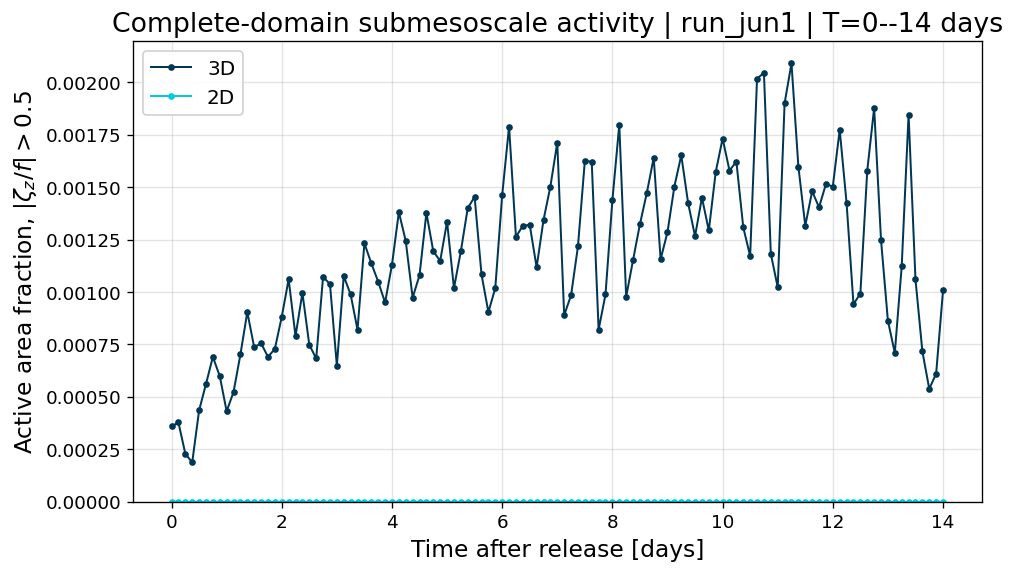

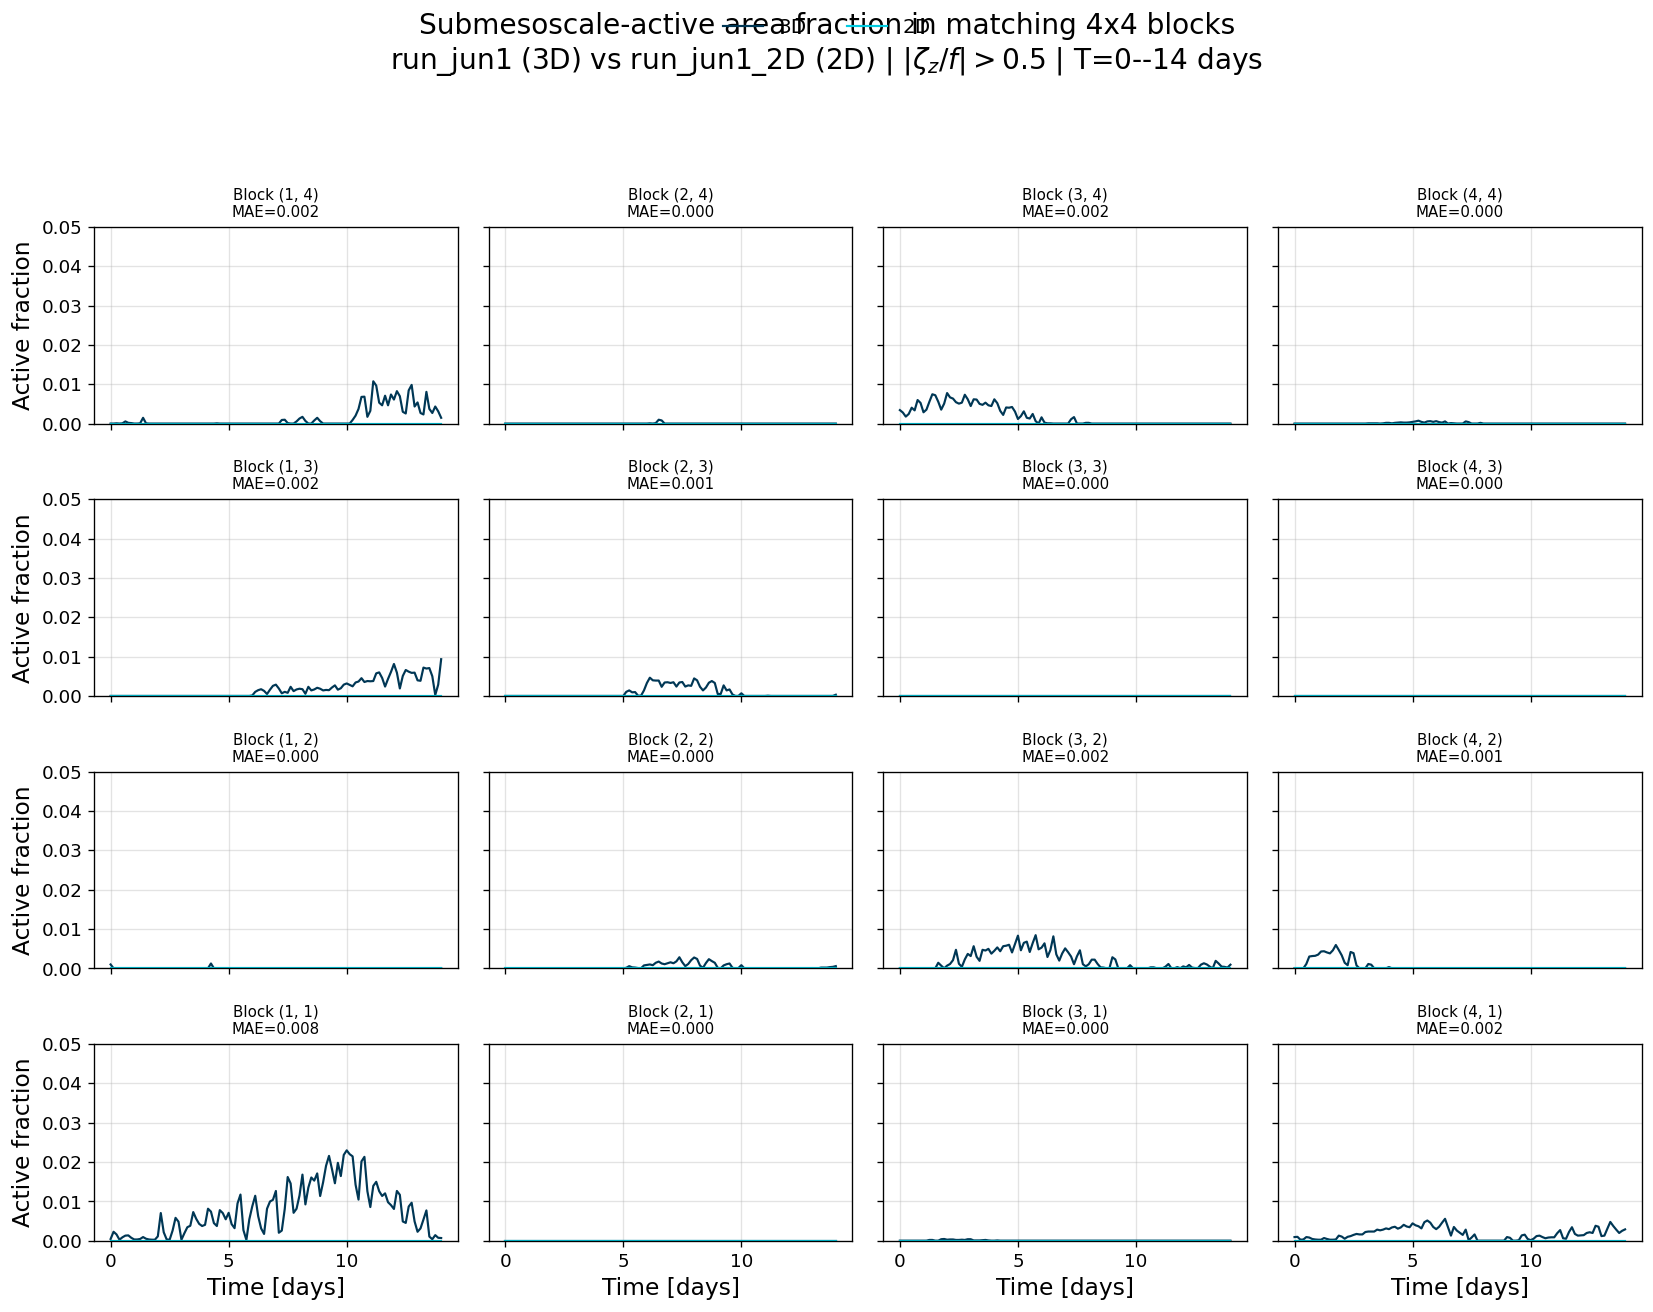

In [7]:
# ============================================================
# 6B. SELECTED-CASE ACTIVE-AREA FRACTION FIGURES
# ============================================================

# Complete-domain time series for the selected pair.
fig, ax = plt.subplots(figsize=(8.5, 5.0))

ax.plot(
    active_area_df["time_days"],
    active_area_df["active_fraction_3d"],
    marker="o",
    markersize=3,
    label="3D",
)
ax.plot(
    active_area_df["time_days"],
    active_area_df["active_fraction_2d"],
    marker="o",
    markersize=3,
    label="2D",
)

ax.set_xlabel("Time after release [days]")
ax.set_ylabel(
    rf"Active area fraction, "
    rf"$|\zeta_z/f|>{ACTIVE_RO_THRESHOLD:g}$"
)
ax.set_ylim(bottom=0.0)
ax.set_title(
    f"Complete-domain submesoscale activity | "
    f"{CASE_3D} | {comparison_time_label()}"
)
ax.legend()
fig.tight_layout()

if SAVE_FIGURES:
    fig.savefig(
        FIG_DIR
        / "active_area_fraction_complete_domain_selected_case.png",
        dpi=300,
        bbox_inches="tight",
    )

plt.show()


# Same physical 4x4 subdivision for the 3D and 2D cases.
fig, axes = plt.subplots(
    ACTIVE_SUBDOMAINS_Y,
    ACTIVE_SUBDOMAINS_X,
    figsize=(14.0, 11.0),
    sharex=True,
    sharey=True,
)

global_max = float(
    np.nanmax(
        active_subdomain_df[
            [
                "active_fraction_3d",
                "active_fraction_2d",
            ]
        ].to_numpy()
    )
)
y_max = min(1.0, max(0.05, 1.05 * global_max))

for block_y in range(ACTIVE_SUBDOMAINS_Y):
    for block_x in range(ACTIVE_SUBDOMAINS_X):
        # Reverse the displayed row order so north is shown at the top.
        display_row = ACTIVE_SUBDOMAINS_Y - 1 - block_y
        ax = axes[display_row, block_x]

        subset = active_subdomain_df[
            (
                active_subdomain_df[
                    "block_y_south_to_north"
                ]
                == block_y
            )
            & (
                active_subdomain_df[
                    "block_x_west_to_east"
                ]
                == block_x
            )
        ].sort_values("time_days")

        ax.plot(
            subset["time_days"],
            subset["active_fraction_3d"],
            linewidth=1.3,
            label="3D",
        )
        ax.plot(
            subset["time_days"],
            subset["active_fraction_2d"],
            linewidth=1.3,
            label="2D",
        )

        block_mae = float(
            subset[
                "active_fraction_error_absolute"
            ].mean()
        )

        ax.set_title(
            f"Block ({block_x + 1}, {block_y + 1})"
            f"\nMAE={block_mae:.3f}",
            fontsize=9,
        )
        ax.set_ylim(0.0, y_max)

        if display_row == ACTIVE_SUBDOMAINS_Y - 1:
            ax.set_xlabel("Time [days]")

        if block_x == 0:
            ax.set_ylabel("Active fraction")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    frameon=False,
)
fig.suptitle(
    f"Submesoscale-active area fraction in matching 4x4 blocks\n"
    f"{CASE_3D} (3D) vs {CASE_2D} (2D) | "
    f"$|\\zeta_z/f|>{ACTIVE_RO_THRESHOLD:g}$ | "
    f"{comparison_time_label()}",
    y=0.995,
)
fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.95))

if SAVE_FIGURES:
    fig.savefig(
        FIG_DIR / "active_area_fraction_matching_4x4_blocks.png",
        dpi=300,
        bbox_inches="tight",
    )

plt.show()


Cases included in complete-domain summary:
  run_jun1 vs run_jun1_2D
  [ 1/1] run_jun1: 113 matched snapshots


,case_3d,case_2d,n_matched_times,mean_active_fraction_3d,mean_active_fraction_2d,bias_2d_minus_3d,mae,rmse,temporal_spearman
0,run_jun1,run_jun1_2D,113,0.001161,0.0,-0.001161,0.001161,0.001229,NaN


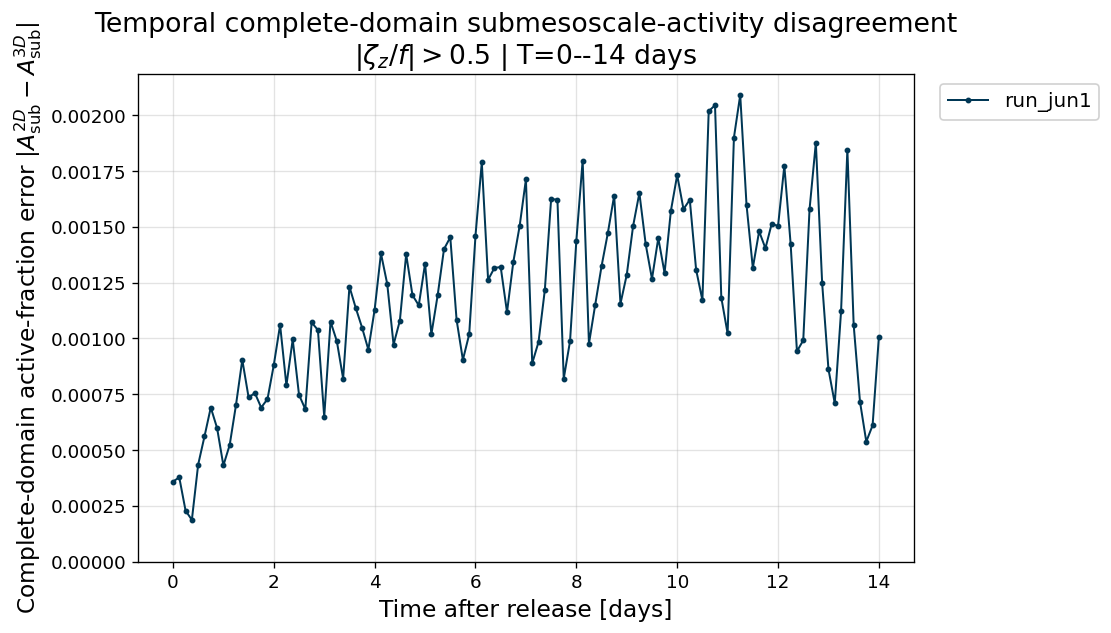

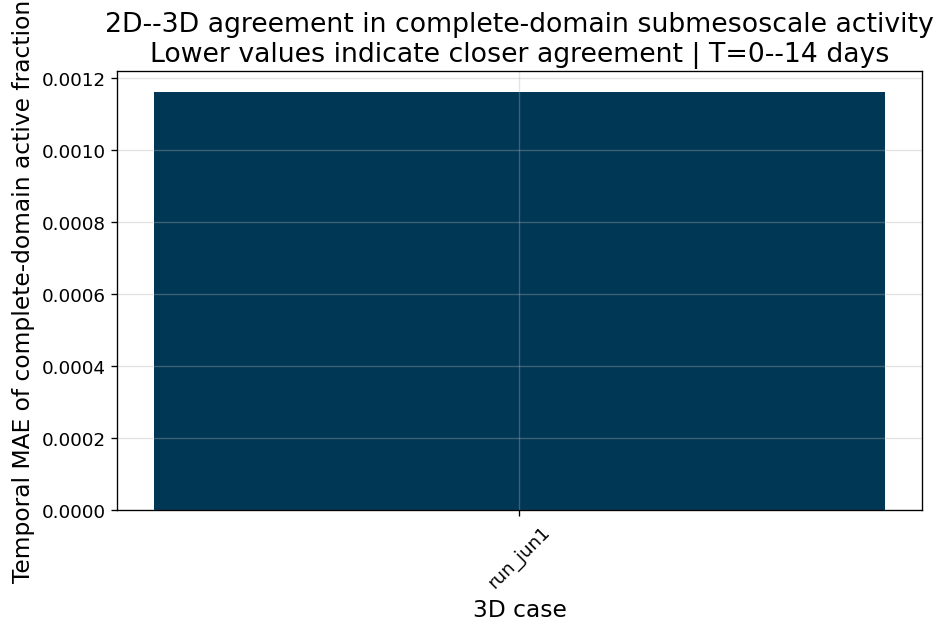

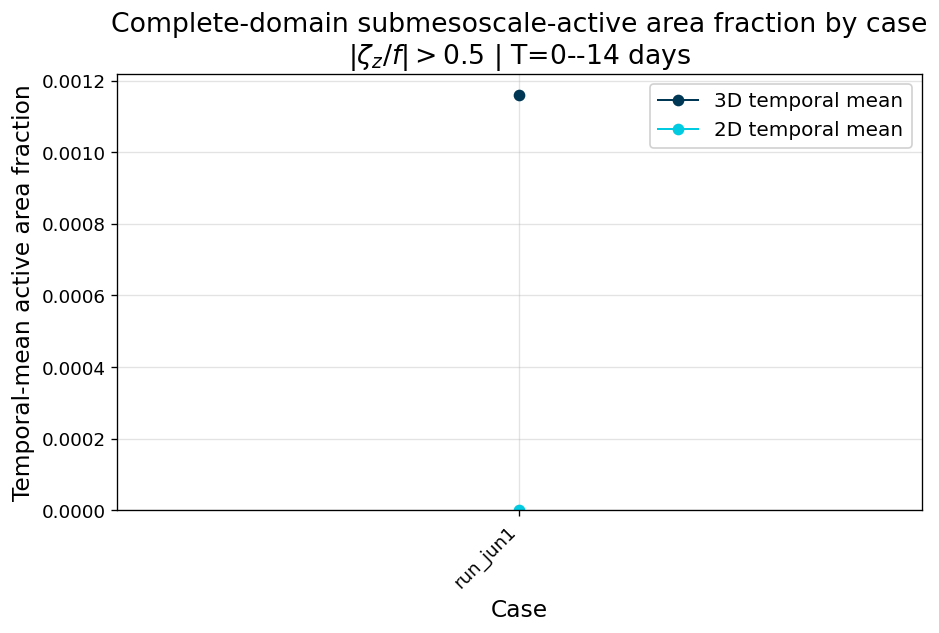

In [8]:
# ============================================================
# 6C. COMPLETE-DOMAIN ACTIVE-AREA SUMMARY ACROSS CASES
# ============================================================

if SUMMARY_CASES_3D is None:
    summary_cases_3d = discover_2d_3d_case_pairs(INPUT_DIR)
else:
    summary_cases_3d = list(SUMMARY_CASES_3D)

summary_cases_3d = [
    case
    for case in summary_cases_3d
    if case not in set(EXCLUDE_SUMMARY_CASES_3D)
]

if not summary_cases_3d:
    raise RuntimeError(
        "No 2D--3D NetCDF case pairs were found for the summary."
    )

print("Cases included in complete-domain summary:")
for case_name in summary_cases_3d:
    print(f"  {case_name} vs {case_name}_2D")

all_case_active_records = []
all_case_summary_records = []

for case_index, case_3d in enumerate(summary_cases_3d, start=1):
    case_2d = f"{case_3d}_2D"

    path_3d = INPUT_DIR / f"{case_3d}.nc"
    path_2d = INPUT_DIR / f"{case_2d}.nc"

    config_case_3d = optional_case_config(case_3d)
    config_case_2d = optional_case_config(case_2d)

    case_records = []

    with xr.open_dataset(
        path_3d,
        decode_times=False,
        cache=False,
    ) as ds_case_3d, xr.open_dataset(
        path_2d,
        decode_times=False,
        cache=False,
    ) as ds_case_2d:

        time_3d = flow_elapsed_days(
            config_case_3d,
            int(ds_case_3d.sizes["T"]),
        )
        time_2d = flow_elapsed_days(
            config_case_2d,
            int(ds_case_2d.sizes["T"]),
        )

        valid_3d = np.flatnonzero(
            time_range_mask(time_3d)
        )
        valid_2d = np.flatnonzero(
            time_range_mask(time_2d)
        )

        matched_local_3d, matched_local_2d = (
            nearest_time_matches(
                time_3d[valid_3d],
                time_2d[valid_2d],
            )
        )

        matched_3d = valid_3d[matched_local_3d]
        matched_2d = valid_2d[matched_local_2d]

        for idx_3d, idx_2d in zip(matched_3d, matched_2d):
            ro_3d = flow_diagnostics_snapshot(
                ds_case_3d,
                idx_3d,
                FLOW_LEVEL_INDICES_3D,
                F0,
            )["ro"]
            ro_2d = flow_diagnostics_snapshot(
                ds_case_2d,
                idx_2d,
                FLOW_LEVEL_INDICES_2D,
                F0,
            )["ro"]

            fraction_3d = active_area_fraction(ro_3d)
            fraction_2d = active_area_fraction(ro_2d)
            time_day = float(time_3d[idx_3d])

            record = {
                "case_3d": case_3d,
                "case_2d": case_2d,
                "time_days": time_day,
                "active_fraction_3d": fraction_3d,
                "active_fraction_2d": fraction_2d,
                "error_signed": fraction_2d - fraction_3d,
                "error_absolute": abs(
                    fraction_2d - fraction_3d
                ),
            }

            case_records.append(record)
            all_case_active_records.append(record)

    case_df = pd.DataFrame(case_records)

    if case_df.empty:
        print(
            f"  WARNING: no matched snapshots for {case_3d}; "
            "case omitted."
        )
        continue

    values_3d = case_df["active_fraction_3d"].to_numpy()
    values_2d = case_df["active_fraction_2d"].to_numpy()
    errors = values_2d - values_3d

    if (
        len(case_df) >= 2
        and not np.allclose(values_3d, values_3d[0])
        and not np.allclose(values_2d, values_2d[0])
    ):
        temporal_spearman = float(
            spearmanr(values_2d, values_3d).statistic
        )
    else:
        temporal_spearman = np.nan

    all_case_summary_records.append(
        {
            "case_3d": case_3d,
            "case_2d": case_2d,
            "n_matched_times": int(len(case_df)),
            "mean_active_fraction_3d": float(
                np.mean(values_3d)
            ),
            "mean_active_fraction_2d": float(
                np.mean(values_2d)
            ),
            "bias_2d_minus_3d": float(np.mean(errors)),
            "mae": float(np.mean(np.abs(errors))),
            "rmse": float(
                np.sqrt(np.mean(errors ** 2))
            ),
            "temporal_spearman": temporal_spearman,
        }
    )

    print(
        f"  [{case_index:2d}/{len(summary_cases_3d)}] "
        f"{case_3d}: {len(case_df)} matched snapshots"
    )

all_case_active_df = pd.DataFrame(all_case_active_records)
active_case_summary_df = pd.DataFrame(
    all_case_summary_records
).sort_values("mae")

if active_case_summary_df.empty:
    raise RuntimeError(
        "No complete-domain case summaries could be calculated."
    )

display(active_case_summary_df)

if SAVE_OUTPUTS:
    all_case_active_df.to_csv(
        METRICS_DIR
        / "active_area_fraction_complete_domain_all_cases_timeseries.csv",
        index=False,
    )
    active_case_summary_df.to_csv(
        METRICS_DIR
        / "active_area_fraction_complete_domain_case_summary.csv",
        index=False,
    )


# Figure 1: temporal absolute error for all case pairs.
fig, ax = plt.subplots(figsize=(9.5, 5.5))

for case_name in active_case_summary_df["case_3d"]:
    subset = all_case_active_df[
        all_case_active_df["case_3d"] == case_name
    ].sort_values("time_days")

    ax.plot(
        subset["time_days"],
        subset["error_absolute"],
        marker="o",
        markersize=2.5,
        linewidth=1.2,
        label=case_name,
    )

ax.set_xlabel("Time after release [days]")
ax.set_ylabel(
    r"Complete-domain active-fraction error "
    r"$|A_{\mathrm{sub}}^{2D}-A_{\mathrm{sub}}^{3D}|$"
)
ax.set_ylim(bottom=0.0)
ax.set_title(
    "Temporal complete-domain submesoscale-activity disagreement\n"
    f"$|\\zeta_z/f|>{ACTIVE_RO_THRESHOLD:g}$ | "
    f"{comparison_time_label()}"
)
ax.legend(
    bbox_to_anchor=(1.02, 1.0),
    loc="upper left",
)
fig.tight_layout()

if SAVE_FIGURES:
    fig.savefig(
        FIG_DIR
        / "active_area_fraction_all_cases_absolute_error_timeseries.png",
        dpi=300,
        bbox_inches="tight",
    )

plt.show()


# Figure 2: direct ranking of case agreement using temporal MAE.
ranking_df = active_case_summary_df.sort_values(
    "mae",
    ascending=True,
)

fig, ax = plt.subplots(
    figsize=(
        max(8.0, 0.75 * len(ranking_df)),
        5.5,
    )
)

ax.bar(
    ranking_df["case_3d"],
    ranking_df["mae"],
)

ax.set_xlabel("3D case")
ax.set_ylabel(
    r"Temporal MAE of complete-domain active fraction"
)
ax.set_ylim(bottom=0.0)
ax.set_title(
    "2D--3D agreement in complete-domain submesoscale activity\n"
    "Lower values indicate closer agreement | "
    f"{comparison_time_label()}"
)
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()

if SAVE_FIGURES:
    fig.savefig(
        FIG_DIR
        / "active_area_fraction_complete_domain_case_ranking.png",
        dpi=300,
        bbox_inches="tight",
    )

plt.show()


# Figure 3: absolute mean active fraction retained alongside the error.
mean_df = active_case_summary_df.sort_values("case_3d")
x_positions = np.arange(len(mean_df))

fig, ax = plt.subplots(
    figsize=(
        max(8.0, 0.75 * len(mean_df)),
        5.5,
    )
)

ax.plot(
    x_positions,
    mean_df["mean_active_fraction_3d"],
    marker="o",
    label="3D temporal mean",
)
ax.plot(
    x_positions,
    mean_df["mean_active_fraction_2d"],
    marker="o",
    label="2D temporal mean",
)

ax.set_xticks(x_positions)
ax.set_xticklabels(
    mean_df["case_3d"],
    rotation=45,
    ha="right",
)
ax.set_xlabel("Case")
ax.set_ylabel("Temporal-mean active area fraction")
ax.set_ylim(bottom=0.0)
ax.set_title(
    "Complete-domain submesoscale-active area fraction by case\n"
    f"$|\\zeta_z/f|>{ACTIVE_RO_THRESHOLD:g}$ | "
    f"{comparison_time_label()}"
)
ax.legend()
fig.tight_layout()

if SAVE_FIGURES:
    fig.savefig(
        FIG_DIR
        / "active_area_fraction_complete_domain_case_means.png",
        dpi=300,
        bbox_inches="tight",
    )

plt.show()


In [9]:
# ============================================================
# 7. LOAD SAVED CLUSTERING TIME SERIES
# ============================================================

def clustering_metrics_path(case_name, particle_tag, config):
    level_tag = "k" + "-".join(
        str(k) for k in config["level_indices"]
    )
    release_index = int(config["release_time_index"])

    expected = (
        RESULTS_ROOT
        / case_name
        / "metrics"
        / "voronoi"
        / (
            f"{particle_tag}_{level_tag}_"
            f"release_t{release_index:04d}_"
            "clustered_state_timeseries.nc"
        )
    )

    if expected.exists():
        return expected

    candidates = sorted(
        (
            RESULTS_ROOT
            / case_name
            / "metrics"
            / "voronoi"
        ).glob(
            f"{particle_tag}_*_clustered_state_timeseries.nc"
        ),
        key=lambda p: p.stat().st_mtime,
    )

    if not candidates:
        raise FileNotFoundError(
            "No clustered-state timeseries was found for "
            f"{case_name}, particle tag {particle_tag}.\n"
            "Run analyze_particles.ipynb for this case first."
        )

    warnings.warn(
        f"Using fallback clustering file {candidates[-1].name}"
    )
    return candidates[-1]


def cluster_flag_name(ds):
    for name in [
        "cluster_flag_tolerant",
        "cluster_flag",
        "clustered_state",
    ]:
        if name in ds:
            return name

    raise KeyError(
        "No recognized cluster-flag variable found. "
        f"Available variables: {list(ds.data_vars)}"
    )


def voronoi_area_name(ds):
    for name in [
        "voronoi_area_norm",
        "normalized_voronoi_area",
        "area_norm",
    ]:
        if name in ds:
            return name

    raise KeyError(
        "No recognized normalized Voronoï-area variable found. "
        f"Available variables: {list(ds.data_vars)}"
    )


cluster_data_3d = {}
cluster_data_2d = {}

for particle_class in common_particle_classes:
    item_3d = trajectories_3d[particle_class]
    item_2d = trajectories_2d[particle_class]

    path_3d = clustering_metrics_path(
        CASE_3D,
        item_3d["tag"],
        config_3d,
    )
    path_2d = clustering_metrics_path(
        CASE_2D,
        item_2d["tag"],
        config_2d,
    )

    cluster_data_3d[particle_class] = xr.open_dataset(path_3d)
    cluster_data_2d[particle_class] = xr.open_dataset(path_2d)

    print(f"\n{particle_class}")
    print(f"  3D clustering: {path_3d}")
    print(f"  2D clustering: {path_2d}")



passive
  3D clustering: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1\metrics\voronoi\passive_k0_release_t0000_clustered_state_timeseries.nc
  2D clustering: C:\Users\Jelle Gortemaker\Documents\Thesis\z.parcels_postprocessing\results\run_jun1_2D\metrics\voronoi\passive_k0_release_t0000_clustered_state_timeseries.nc


FileNotFoundError: No clustered-state timeseries was found for run_jun1, particle tag smmrg_taueff30s_Steff4p21421em05.
Run analyze_particles.ipynb for this case first.

In [ ]:
# ============================================================
# 8. TEMPORAL PARTICLE AGREEMENT METRICS
# ============================================================

particle_records = []
spatial_difference_maps = {}

for particle_class in common_particle_classes:
    item_3d = trajectories_3d[particle_class]
    item_2d = trajectories_2d[particle_class]

    ds_traj_3d = item_3d["ds"]
    ds_traj_2d = item_2d["ds"]

    ds_cluster_3d = cluster_data_3d[particle_class]
    ds_cluster_2d = cluster_data_2d[particle_class]

    flag_name_3d = cluster_flag_name(ds_cluster_3d)
    flag_name_2d = cluster_flag_name(ds_cluster_2d)
    area_name_3d = voronoi_area_name(ds_cluster_3d)
    area_name_2d = voronoi_area_name(ds_cluster_2d)

    obs_values_3d = np.asarray(
        ds_cluster_3d["obs"].values,
        dtype=int,
    )
    obs_values_2d = np.asarray(
        ds_cluster_2d["obs"].values,
        dtype=int,
    )

    trajectory_times_3d = elapsed_days_from_trajectory(ds_traj_3d)
    trajectory_times_2d = elapsed_days_from_trajectory(ds_traj_2d)

    cluster_times_3d = trajectory_times_3d[obs_values_3d]
    cluster_times_2d = trajectory_times_2d[obs_values_2d]

    matched_3d, matched_2d = nearest_time_matches(
        cluster_times_3d,
        cluster_times_2d,
    )

    xname_3d, yname_3d = mclus.get_xy_names(ds_traj_3d)
    xname_2d, yname_2d = mclus.get_xy_names(ds_traj_2d)

    label = item_3d["label"]
    tau_eff = float(item_3d["tau_eff_seconds"])

    spatial_difference_maps[particle_class] = {}

    for local_3d, local_2d in zip(matched_3d, matched_2d):
        obs_3d = int(obs_values_3d[local_3d])
        obs_2d = int(obs_values_2d[local_2d])
        time_days = float(cluster_times_3d[local_3d])

        if not time_is_selected(time_days):
            continue

        flags_3d = np.asarray(
            ds_cluster_3d[flag_name_3d].isel(obs=local_3d).values,
            dtype=float,
        )
        flags_2d = np.asarray(
            ds_cluster_2d[flag_name_2d].isel(obs=local_2d).values,
            dtype=float,
        )

        fraction_3d = float(np.nanmean(flags_3d))
        fraction_2d = float(np.nanmean(flags_2d))

        signed_error = fraction_2d - fraction_3d
        absolute_error = abs(signed_error)

        relative_error = (
            signed_error / fraction_3d
            if fraction_3d >= CLUSTER_FRACTION_RELATIVE_ERROR_FLOOR
            else np.nan
        )

        area_3d = np.asarray(
            ds_cluster_3d[area_name_3d].isel(obs=local_3d).values,
            dtype=float,
        )
        area_2d = np.asarray(
            ds_cluster_2d[area_name_2d].isel(obs=local_2d).values,
            dtype=float,
        )

        voronoi_w1, voronoi_w1_norm = normalized_wasserstein(
            area_2d,
            area_3d,
            max_samples=None,
        )

        x_3d = np.asarray(
            ds_traj_3d[xname_3d].isel(obs=obs_3d).values,
            dtype=float,
        )
        y_3d = np.asarray(
            ds_traj_3d[yname_3d].isel(obs=obs_3d).values,
            dtype=float,
        )
        x_2d = np.asarray(
            ds_traj_2d[xname_2d].isel(obs=obs_2d).values,
            dtype=float,
        )
        y_2d = np.asarray(
            ds_traj_2d[yname_2d].isel(obs=obs_2d).values,
            dtype=float,
        )

        density_3d, x_edges, y_edges = normalized_particle_histogram(
            x_3d,
            y_3d,
            domain,
            N_BLOCKS_X,
            N_BLOCKS_Y,
        )
        density_2d, _, _ = normalized_particle_histogram(
            x_2d,
            y_2d,
            domain,
            N_BLOCKS_X,
            N_BLOCKS_Y,
        )

        spatial_rho, spatial_nrmse = coarse_particle_agreement(
            density_2d,
            density_3d,
            min_valid_blocks=MIN_VALID_BLOCKS_FOR_CORRELATION,
        )

        particle_records.append(
            {
                "particle_class": particle_class,
                "particle_label": label,
                "tau_eff_seconds": tau_eff,
                "time_days": time_days,
                "obs_3d": obs_3d,
                "obs_2d": obs_2d,
                "clustered_fraction_3d": fraction_3d,
                "clustered_fraction_2d": fraction_2d,
                "cluster_error_signed": signed_error,
                "cluster_error_absolute": absolute_error,
                "cluster_error_relative": relative_error,
                "voronoi_wasserstein": voronoi_w1,
                "voronoi_wasserstein_iqr_normalized": voronoi_w1_norm,
                "particle_spatial_spearman": spatial_rho,
                "particle_spatial_nrmse": spatial_nrmse,
            }
        )

        for requested_time in SPATIAL_MAP_TIME_DAYS:
            key = f"{requested_time:.6f}"
            current = spatial_difference_maps[particle_class].get(key)
            time_difference = abs(time_days - requested_time)

            if current is None or time_difference < current["time_difference"]:
                spatial_difference_maps[particle_class][key] = {
                    "requested_time": float(requested_time),
                    "actual_time": time_days,
                    "time_difference": time_difference,
                    "density_difference": density_2d - density_3d,
                    "x_edges": x_edges,
                    "y_edges": y_edges,
                }

particle_metrics_df = pd.DataFrame(particle_records)
display(particle_metrics_df.head())

particle_metrics_ds = (
    particle_metrics_df
    .set_index(["particle_class", "time_days"])
    .to_xarray()
)

particle_metrics_ds.attrs.update(
    {
        "case_3d": CASE_3D,
        "case_2d": CASE_2D,
        "description": (
            "Time-dependent 2D-3D particle agreement metrics."
        ),
        "coarse_grid_nx": int(N_BLOCKS_X),
        "coarse_grid_ny": int(N_BLOCKS_Y),
        "cluster_error_sign": (
            "positive means stronger clustered fraction in 2D"
        ),
    }
)

if SAVE_OUTPUTS:
    particle_metrics_df.to_csv(
        METRICS_DIR / "particle_agreement_metrics.csv",
        index=False,
    )
    particle_metrics_ds.to_netcdf(
        METRICS_DIR / "particle_agreement_metrics.nc"
    )

print("Finished particle agreement comparison.")


In [ ]:
# ============================================================
# 9. TIME-SERIES FIGURES
# ============================================================

fig, ax = plt.subplots(figsize=(8.5, 5.0))

for variable, label in FLOW_DISTRIBUTION_VARIABLES.items():
    subset = flow_distance_df[
        flow_distance_df["variable"] == variable
    ].sort_values("time_days")

    ax.plot(
        subset["time_days"],
        subset["wasserstein_iqr_normalized"],
        marker="o",
        markersize=3,
        label=label,
    )

ax.set_xlabel("Time after release [days]")
ax.set_ylabel(
    r"IQR-normalized Wasserstein distance, "
    r"$W_1/\mathrm{IQR}_{3D}$"
)
ax.set_title(
    f"Flow-distribution disagreement | {CASE_3D} vs {CASE_2D} | "
    f"{comparison_time_label()}"
)
ax.legend()
fig.tight_layout()

if SAVE_FIGURES:
    fig.savefig(
        FIG_DIR / "flow_distribution_wasserstein_time_series.png",
        dpi=300,
        bbox_inches="tight",
    )

plt.show()


fig, ax = plt.subplots(figsize=(8.5, 5.0))

for particle_class in common_particle_classes:
    subset = particle_metrics_df[
        particle_metrics_df["particle_class"] == particle_class
    ].sort_values("time_days")

    ax.plot(
        subset["time_days"],
        subset["voronoi_wasserstein"],
        marker="o",
        markersize=3,
        label=subset["particle_label"].iloc[0],
    )

ax.set_xlabel("Time after release [days]")
ax.set_ylabel("Wasserstein distance of normalized Voronoï area")
ax.set_title(
    f"Particle-distribution disagreement | {CASE_3D} vs {CASE_2D} | "
    f"{comparison_time_label()}"
)
ax.legend()
fig.tight_layout()

if SAVE_FIGURES:
    fig.savefig(
        FIG_DIR / "voronoi_wasserstein_time_series.png",
        dpi=300,
        bbox_inches="tight",
    )

plt.show()


fig, ax = plt.subplots(figsize=(8.5, 5.0))

for particle_class in common_particle_classes:
    subset = particle_metrics_df[
        particle_metrics_df["particle_class"] == particle_class
    ].sort_values("time_days")

    ax.plot(
        subset["time_days"],
        subset["cluster_error_absolute"],
        marker="o",
        markersize=3,
        label=subset["particle_label"].iloc[0],
    )

ax.set_xlabel("Time after release [days]")
ax.set_ylabel(r"$|F_c^{2D}-F_c^{3D}|$")
ax.set_title(
    f"Clustered-fraction error | {CASE_3D} vs {CASE_2D} | "
    f"{comparison_time_label()}"
)
ax.legend()
fig.tight_layout()

if SAVE_FIGURES:
    fig.savefig(
        FIG_DIR / "cluster_fraction_absolute_error_time_series.png",
        dpi=300,
        bbox_inches="tight",
    )

plt.show()


fig, ax = plt.subplots(figsize=(8.5, 5.0))

for particle_class in common_particle_classes:
    subset = particle_metrics_df[
        particle_metrics_df["particle_class"] == particle_class
    ].sort_values("time_days")

    ax.plot(
        subset["time_days"],
        subset["particle_spatial_spearman"],
        marker="o",
        markersize=3,
        label=subset["particle_label"].iloc[0],
    )

ax.axhline(0.0, linewidth=1.0)
ax.set_xlabel("Time after release [days]")
ax.set_ylabel("Spearman correlation of coarse particle density")
ax.set_ylim(-1.05, 1.05)
ax.set_title(
    f"Coarse particle-field agreement | {CASE_3D} vs {CASE_2D} | "
    f"{comparison_time_label()}"
)
ax.legend()
fig.tight_layout()

if SAVE_FIGURES:
    fig.savefig(
        FIG_DIR / "particle_spatial_spearman_time_series.png",
        dpi=300,
        bbox_inches="tight",
    )

plt.show()


In [ ]:
# ============================================================
# 10. OPTIONAL PARTICLE-DENSITY DIFFERENCE MAPS
# ============================================================

if PLOT_SPATIAL_DIFFERENCE_MAPS:
    for particle_class in common_particle_classes:
        label = trajectories_3d[particle_class]["label"]

        for item in spatial_difference_maps[particle_class].values():
            difference = item["density_difference"]
            x_edges = item["x_edges"] / 1000.0
            y_edges = item["y_edges"] / 1000.0

            fig, ax = plt.subplots(figsize=(6.5, 5.5))

            vmax = float(np.nanmax(np.abs(difference)))
            if not np.isfinite(vmax) or vmax == 0.0:
                vmax = 1.0

            mesh = ax.pcolormesh(
                x_edges,
                y_edges,
                difference.T,
                shading="auto",
                cmap="RdBu_r",
                vmin=-vmax,
                vmax=vmax,
            )

            colorbar = fig.colorbar(mesh, ax=ax)
            colorbar.set_label(
                r"Coarse particle-density difference "
                r"$(p_{\mathrm{2D}}-p_{\mathrm{3D}})$"
            )

            ax.set_xlabel("x [km]")
            ax.set_ylabel("y [km]")
            ax.set_aspect("equal")
            ax.set_title(
                f"{label} | requested T={item['requested_time']:.1f} d, "
                f"actual T={item['actual_time']:.2f} d"
            )

            fig.tight_layout()

            if SAVE_FIGURES:
                safe_class = particle_class.replace("/", "_")
                time_tag = (
                    f"{item['requested_time']:.1f}d"
                    .replace(".", "p")
                )
                fig.savefig(
                    FIG_DIR
                    / (
                        "particle_density_difference_"
                        f"{safe_class}_{time_tag}.png"
                    ),
                    dpi=300,
                    bbox_inches="tight",
                )

            plt.show()


In [ ]:
# ============================================================
# 11. COMPACT SUMMARIES AND CLEANUP
# The full time series remains the primary result.
# ============================================================

flow_summary = (
    flow_distance_df
    .groupby(["variable", "label"], as_index=False)
    .agg(
        median_wasserstein=("wasserstein_distance", "median"),
        p95_wasserstein=(
            "wasserstein_distance",
            lambda x: np.nanpercentile(x, 95),
        ),
        median_iqr_normalized=(
            "wasserstein_iqr_normalized",
            "median",
        ),
        p95_iqr_normalized=(
            "wasserstein_iqr_normalized",
            lambda x: np.nanpercentile(x, 95),
        ),
    )
)

particle_summary = (
    particle_metrics_df
    .groupby(
        [
            "particle_class",
            "particle_label",
            "tau_eff_seconds",
        ],
        as_index=False,
    )
    .agg(
        median_cluster_abs_error=(
            "cluster_error_absolute",
            "median",
        ),
        p95_cluster_abs_error=(
            "cluster_error_absolute",
            lambda x: np.nanpercentile(x, 95),
        ),
        median_voronoi_w1=(
            "voronoi_wasserstein",
            "median",
        ),
        p95_voronoi_w1=(
            "voronoi_wasserstein",
            lambda x: np.nanpercentile(x, 95),
        ),
        median_spatial_spearman=(
            "particle_spatial_spearman",
            "median",
        ),
        median_spatial_nrmse=(
            "particle_spatial_nrmse",
            "median",
        ),
    )
)


print("Complete-domain active-area case summary")
display(active_case_summary_df)

print("Flow summary")
display(flow_summary)

print("Particle summary")
display(particle_summary)

if SAVE_OUTPUTS:
    flow_summary.to_csv(
        METRICS_DIR / "flow_distribution_distance_summary.csv",
        index=False,
    )
    particle_summary.to_csv(
        METRICS_DIR / "particle_agreement_summary.csv",
        index=False,
    )

for item in trajectories_3d.values():
    item["ds"].close()

for item in trajectories_2d.values():
    item["ds"].close()

for ds in cluster_data_3d.values():
    ds.close()

for ds in cluster_data_2d.values():
    ds.close()

print(f"Saved metrics to: {METRICS_DIR}")
print(f"Saved figures to: {FIG_DIR}")
print("Done.")
